# Diagrams and Figures
This notebook is intended to create the figures and diagrams of the method section that will go in the publication. It should complement the PPT containing workflows and other diagrams


## Import relevant modules

In [6]:
import os
# import cv2
# import json
# import datetime
import numpy as np
# import pandas as pd
# import pydicom as pyd
# import nibabel as nib
import matplotlib.pyplot as plt
# from lmfit import minimize, Parameters

# If the background colour of the plots is the same as the VS theme, check the option jupyter.themeMatplotlibPlots, 
# as indicated at https://stackoverflow.com/questions/75154449/vscode-setup-question-python-plot-background-color
# --> In macOS, go to Code -> Settings -> Settings -> Users -> jupyter:themeMatplotlibPlots

# # Additional PyDicom tools
# from pydicom.dataset import Dataset, FileMetaDataset
# from pydicom.sequence import Sequence

# # Utils for displaying
# from mpl_toolkits.axes_grid1 import make_axes_locatable, axes_size


## Auxiliar Functions

### SPGR 

In [97]:

def relaxationTerm(acquisitionTpar, relaxationTime):

    expTacqRelT = np.exp(- acquisitionTpar / (relaxationTime + 1e-9))
    expTacqRelT *= (relaxationTime > 0.0)
    return expTacqRelT

def E1(TR, T1):
    
    return relaxationTerm(TR,T1)

def E2(TE, T2star):
    
    return relaxationTerm(TE,T2star)

def spgr_signal(s0, t1, tr, flip_angle, te, t2star):
    
    fa_radians = np.deg2rad(flip_angle)
    t2contrib = E2(TE=te, T2star=t2star)
    t1contrib = E1(TR=tr, T1=t1)
    
    num = (1 - t1contrib) 
    den = (1-np.cos(fa_radians)*t1contrib)
    scaling_factor = s0*np.sin(fa_radians)
    s = scaling_factor * t2contrib * num / den

    return s


### Contrast media concentrations

In [98]:
def r1_contrast(baselineT1, relaxivity, ca_concentration_time):
    
    # Units analysis:
    # relaxivity is in L*mmol-1*s-1
    # T1 is in ms
    # concentration of CA is in mM
    # therefore, we need to convert T1 to seconds by multiplying it by 1000:
    r10 = 1.0 / (baselineT1 * 1e-3)
    r1t = relaxivity * ca_concentration_time
    
    r1ct = r10 + r1t

    return r1ct


### Arterial Input Functions

In [99]:
def aif_parker(time_axis, offset=0.0):
    
    tprime = time_axis - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )

    aif_parameters = {
        'A': {'mean': [0.809, 0.330],
            'std': [0.044, 0.040],
            'units': ['mmol.min']*2
            },   
        'T': {'mean': [0.17046, 0.365],
            'std': [0.00073, 0.028],
            'units': ['min']*2
            },
        'SIGMA': {'mean': [0.0563, 0.132],
            'std': [0.0011, 0.021],
            'units': ['min']*2
            },
        'ALFA': {'mean': 1.050,
            'std': 0.017,
            'units': 'mmol'
            },
        'BETA': {'mean': 0.1685,
                'std': 0.0056,
                'units': 'min-1'
                },
        's': {'mean': 38.078,
            'std': 16.78,
            'units': 'min-1'
            },
        'tau': {'mean': 0.483,
            'std': 0.015,
            'units': 'min'
            }            
    }
    
    Cp = aif_parameters['ALFA']['mean'] * np.exp(-aif_parameters['BETA']['mean'] * tprime)
    Cp /= ( 1 + np.exp(-aif_parameters['s']['mean'] * ( tprime - aif_parameters['tau']['mean'] )) )
    for n in range(2):
        An = aif_parameters['A']['mean'][n] / ( aif_parameters['SIGMA']['mean'][n] * np.sqrt(2 * np.pi) )
        arg_exp = - ( (tprime - aif_parameters['T']['mean'][n])**2 ) / ( 2 * (aif_parameters['SIGMA']['mean'][n])**2 )
        Cp += ( An * np.exp(arg_exp) )
    
    Cp *= (tprime > 0.0)

    return Cp
    
    
def aif_wang(time_axis, mode='LD', offset=0.0):
    
    tprime = time_axis - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )
    if mode == 'LD':
        aif_parameters = {
            'Ascale': {'mean': 0.31,
                    'std': 0.14,
                    'cv': 0.44,
                    'units': 'mmol'
                },
            'BETA': {'mean': 0.70,
                        'std': 0.15,
                        'cv': 0.22,
                        'units': 'min-1' 
                        },
            'A': {'mean': [5.84, 0.46],
                        'std': [2.47, 0.24],
                        'cv': [0.42, 0.52],
                        'units': ['']*2 
                },
            'SIGMA': {'mean': [0.09, 0.12],
                        'std': [0.03, 0.08],
                        'cv': [0.38, 0.65],
                        'units':['min']*2 
                },
            'T': {'mean': [0.20, 0.62],
                        'std': [0.08, 0.09],
                        'cv': [0.40, 0.15],
                        'units': ['min']*2 
            },
            'R2': {'mean': 0.95,
                    'std': 0.02,
                    'cv': 0.02,
                    'units': ''
            }
        }
        
        Cp = 1.0
        for n in range(2):
            arg_exp = - ( (tprime - aif_parameters['T']['mean'][n])**2 ) / ( 2 * (aif_parameters['SIGMA']['mean'][n])**2 )
            An = aif_parameters['A']['mean'][n]
            Cp += ( An * np.exp(arg_exp) )
        Cp *= aif_parameters['Ascale']['mean'] * np.log(1 + tprime) * np.exp( -aif_parameters['BETA']['mean'] * tprime )

    elif mode == 'SD':
        aif_parameters = {
            'A': {'mean': 0.36,
                  'std': 0.12,
                  'cv': 0.32,
                  'units': 'mmol'
                  },
            'ALFA': {'mean': 8.93,
                     'std': 5.40,
                     'cv': 0.61,
                     'units': 'min-1'
            },
            'GAMMA': {'mean': 0.61,
                     'std': 0.48,
                     'cv': 0.80,
                     'units': 'min-1'
            },
            'R2': {'mean': 0.93,
                     'std': 0.09,
                     'cv': 0.09,
                     'units': ''
            }                        
        }
        Cp1 = aif_parameters['A']['mean']
        Cp2 = ( 1 - np.exp( -aif_parameters['ALFA']['mean'] * tprime ) )
        Cp3 = ( 1 + np.exp( -aif_parameters['GAMMA']['mean'] * tprime ) )
        Cp = Cp1 * Cp2 * Cp3 * 0.5
        Cp *= (tprime > 0.0)

    return Cp


### PK Models

In [ ]:
def tofts(t, ktrans, ve, aif='parker', Hct=0.45, offset=0.0):
    c = tofts2C(t, ktrans, ve, vp=0, aif=aif, Hct=Hct, offset=offset)
    
    return c


def tofts2C(t, ktrans, ve, vp, aif='parker', Hct=0.45, offset=0.0):
    
    if aif == 'parker':
        cb = aif_parker(time_axis=t, offset=offset)
    elif aif == 'wang':
        cb = aif_wang(time_axis=t, mode='LD', offset=offset)
    
    tprime  = t - offset
    tprime = np.abs( tprime * (tprime >= 0.0) )
    
    cp      = cb / (1 - Hct)

    tinit   = 0.0
    tind0   = np.argmax(tprime > 0)
    Ft      = np.full_like(t, 0.0)
    nnt     = 2 * len(t)
    
    for ind_t, tau in enumerate(tprime[tind0:]):
        tau_axis    = np.linspace(tinit, tau, num=nnt)
        # cbint       = np.interp(tau_axis, t, cb)
        cb_tau      = aif_parker(time_axis=tau_axis)
        cp_tau      = cb_tau/(1 - Hct)
        enum        = ktrans * (tau - tau_axis) / ve
        f_tau       = cp_tau * np.exp(-enum)
        Ft[ind_t + tind0] = np.trapezoid(f_tau, tau_axis)

    c = vp * cp + ktrans * Ft

    return c


In [101]:
def setup_subplots_figs(NROWS=1, NCOLS=1, SUBPLTSIZE=4.5, sharex=False, sharey=False):
    fig, ax = plt.subplots(nrows=NROWS, ncols=NCOLS, 
                           figsize = (SUBPLTSIZE*NCOLS, SUBPLTSIZE*NROWS),
                           sharex=sharex, sharey=sharey)
    if hasattr(ax, "__len__"):
        axr = ax.ravel()
    else:
        axr = [ax]
    
    return fig, axr


# Semi-quantitative parameters
Percentage of enhancement (PE), or relative enhancement, indicates the change in pixel intensity due to the contrast application, is the ratio between the change in signal intensity at a specific time, after the contrast injection respect to baseline (i.e. signal intensity with no exogenous contrast). PE is calculated from the pre-contrast and post-contrast images as follows:

\begin{equation}
PE_{i}[\%] = \frac{S(t_i) - S(t_0)}{S(t_0)}\times 100
\end{equation}

Where $S(t_i)$ is the signal intensity at the time point $i$ after contrast injection and $S(t_0)$ the signal intensity before contrast injection $(S(t_0 )≠0)$. PE can be calculated on a pixel basis (i.e. parametric PE map), or over a region-of-interest (ROI), considering the median, or mean, signal intensities over the ROI. In this study, we work on a pixel basis, so all the formulae refer to a single pixel. 

Signal enhancement ratio (SER), characterizes the slope of the signal enhancement curve, which reflects the kinetics of the contrast within the tissue of interest. It is defined as the PE ratio between two timepoints after contrast injection, usually the last and first post-contrast timepoint:

\begin{equation}
SER_{le} = \frac{S(t_e) - S(t_0)}{S(t_l) - S(t_0)}
\end{equation}

Where $S(t_e)$ and $S(t_l)$ are the signal intensity at an early and late timepoints, respectively. Like with PE, $S(t_0)$ is the signal intensity before contrast injection. In this study, the early timepoint considered was the first post-contrast image and the late timepoint, the last timepoint of the sequence. 


# Example: SPGR acquisition

The Spoiled Gradient Echo (SPGR) sequence is one of the most widely used MRI T1W sequences. Because it is a fast sequence that offers flexibility to favour T1 or T2 weighted, it is commonly used in dynamic studies. 
The variable flip angle (VFA) method to measure T1 relaxation, is derived from the signal equation of the SPGR sequence. There is a lot of literature available about this method, so in this notebook I'll cover the major and earlier papers providing the mathematical framework for this method.
The signal equation of the SPGR is a function of multiple parameters [Fram et al., MRI 5(3):201-8; 1987](https://pubmed.ncbi.nlm.nih.gov/3626789/):
\begin{equation} %\label{spgr}
S(\rho, \alpha, T_E, T_R, T_1, T_2^{*}) = k\rho\sin{\alpha}\frac{(1 - e^{-T_R/T_1})}{(1 - (\cos{\alpha})e^{-T_R/T_1})}e^{-T_E/T_2^{*}}
\end{equation}

where $\alpha/T_E/T_R$ are acquisition-controlled parameters: Flip Angle (degrees), Echo Time (ms) and Repetition Time (ms), respectively. $\rho/T_1/T_2$ are intrinsic parameters of the sample: spin density, longitudinal and transverse relaxation constants, respectively. $k$ is an arbitrary constant representing the effect of the $B_1$ inhomogeneity of the RF transmission coil.

Equation [1] (\ref{spgr}) can be rewritten more concisely by considering the following:

<!-- \begin{itemize} -->
<!-- \item  -->
* The arbitrary constant $k$ and the spin density $\rho$ can be grouped into a single parameter $M_0$.
<!-- \item  -->
* The effect of the intrinsic relaxation times $T_1$ and $T_2$, and the acquisition parameters $T_1$ and $T_2$ are grouped in the function forms $E_1(T_1, T_R) = \exp(-T_R/T_1) $ and $E_2(T_2^{*}, T_E) = \exp(-T_E/T_2^{*})$, respectively:
<!-- \end{itemize} -->

\begin{equation}
S(M_0, \alpha, T_E, T_R, T_1, T_2^{*}) = M_0\sin\alpha\frac{1 - E_1(T_1,T_R)}{1 - (\cos\alpha)E_1(T_1,T_R)}E_2(T_2^{*}, T_E)
\end{equation}

Generalising this equation for a time varying $T_1$, we get it formulated as:

\begin{equation}
S(M_0, \alpha, T_E, T_R, T_1(t), T_2^{*}) = M_0\sin\alpha\frac{1 - E_1(T_1(t),T_R)}{1 - (\cos\alpha)E_1(T_1(t),T_R)}E_2(T_2^{*}, T_E)
\end{equation}

By looking at the equation above, we can notice some of the parameters are tissue-dependant (e.g. proton density), other are machine-dependant (i.e. flip angle, repetition time, etc.) and others are both, tissue and machine-dependant (e.g. T1, T2, etc). In order to map cetain tissue, we need to consider all these variables and, perhaps most importantly, how they maximise the contrast between the tissue of interest and the surroundin structures. Moreover, the scanner itself also imposses constraints in some of the parameters, or combination of them (e.g. the slew rate of the gradients system can limit the minimum echo time).

The following table summarises the parameters and their dependance with the tissue, machine and both:

| Parameter |   Tissue dependant  | Scanner dependant |
|   :---:   |   :---:   |   :---:   |
| Proton density |  $\rho$  | $M_0$ |
| Flip Angle (FA) |    | $\alpha$ |
| Echo Time  |   | $T_E$ |
| Repetition Time |   | $T_R$ |
| Longitudinal Relaxation | $T_1$  |  |
| Transverse Relaxation | $T_2^*$  |  |

In order to create an example, we need to assume some values for the parameters in the table above:

Image Parameters:
|Parameter | Values |  Units |
| :----:   | :----: | :----: | 
| TR | 5.2 | ms|
| TE | 2.5 | ms|
| FA | 10  | degree|

Tissue Parameters:
| Tissue | $T_1$ [ms] | $T_2^*$ [ms] |  $M_0$ []  |
| :----: |    :----:  |   :----:   |   :----:   |
|Breast Fat     |  334  | 53 | 100 |
|Glandular Breast Tissue | 1201 | 58 | 10 |
|Breast Malignant Tissue | 876  | 75 | 1000 |
|Blood          |  1434  | 254 | 1 |
|Major Muscle   |   900  |  50 | 100 |
| Water/CSF     |  4000  |  2000 |  100000 |


### MRI parameters (tissue and scanner)

In [21]:
aqcuisition_parameters = {
    'fa': 10,
    'tr': 5.2,
    'te': 2.5,
    'etl': 1,
    'nt': 512,
    'tacq': 10
}
tissue_parameters = {
    'breast_fat': {'t1': 334,
                   't2star': 53,
                   'm0': 100,
                   'colour': 'gray'
                   },
    'breast_glandular': {'t1': 1201,
                         't2star': 58,
                         'm0': 10,
                         'colour': 'magenta'
                         },
    'breast_malignant': {'t1': 876,
                         't2star': 75,
                         'm0': 1000,
                         'colour': 'orange'
                         },
    'blood': {'t1': 1434,
              't2star': 254,
              'm0': 1,
              'colour': 'red'
              },
    'major_muscle': {'t1': 900,
                     't2star': 50,
                     'm0': 100,
                   'colour': 'green'
                     },
    'water_csf': {'t1': 4000,
                  't2star': 2000,
                  'm0': 100000,
                   'colour': 'blue'
                  }
}


In [ ]:
flip_angles = np.linspace(0, 80, num=80)
tr_axis = np.linspace(0, 100*aqcuisition_parameters['tr'], num=128)


### Signal equation

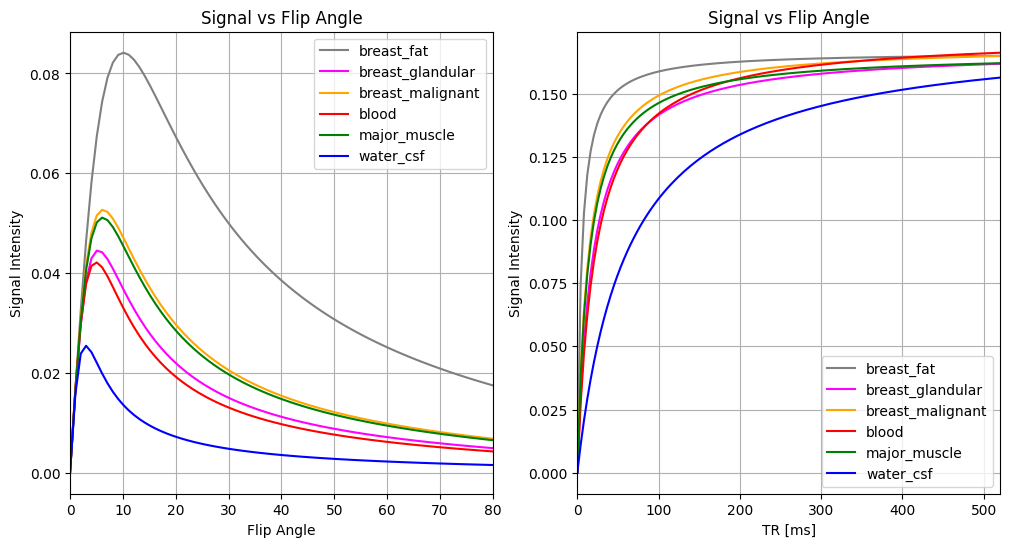

In [125]:
spgr_t = {'fa': {
                 'plot': {'title': 'Signal vs Flip Angle',
                          'axes_name': {'xlabel': 'Flip Angle',
                                        'ylabel': 'Signal Intensity'},
                          'axis_lim': {'xlims': flip_angles[[0, -1]],
                                       'ylims': []}
                         },
                 'xaxis': flip_angles
                },
          'tr': {
                 'plot': {'title': 'Signal vs Flip Angle',
                          'axes_name': {'xlabel': 'TR [ms]',
                                        'ylabel': 'Signal Intensity'},
                          'axis_lim': {'xlims': tr_axis[[0, -1]],
                                       'ylims': []}
                         },
                  'xaxis': tr_axis
          }
}

for tissue, parameters in tissue_parameters.items():
    spgr_t['fa'][tissue] = spgr_signal(1.0,
                                 parameters['t1'], 
                                 aqcuisition_parameters['tr'], 
                                 spgr_t['fa']['xaxis'], 
                                 aqcuisition_parameters['te'],
                                 parameters['t2star'])

    spgr_t['tr'][tissue] = spgr_signal(1.0,
                                 parameters['t1'], 
                                 spgr_t['tr']['xaxis'], 
                                 aqcuisition_parameters['fa'], 
                                 aqcuisition_parameters['te'],
                                 parameters['t2star'])

fig, ax = setup_subplots_figs(NROWS=1, NCOLS=2, SUBPLTSIZE=6.0)

for idx, parameter in enumerate(spgr_t.keys()):
    for tissue in tissue_parameters.keys():
        ax[idx].plot(spgr_t[parameter]['xaxis'], 
                spgr_t[parameter][tissue], 
                color=tissue_parameters[tissue]['colour'], label=tissue)
        
    ax[idx].legend(loc='best')
    ax[idx].set_xlabel(spgr_t[parameter]['plot']['axes_name']['xlabel'])
    ax[idx].set_ylabel(spgr_t[parameter]['plot']['axes_name']['ylabel'])
    ax[idx].set_title(spgr_t[parameter]['plot']['title'])
    ax[idx].set_xlim(spgr_t[parameter]['plot']['axis_lim']['xlims'])
    ax[idx].grid(True)


## Contrast kinetics

#### AIF

Text(0, 0.5, '$C_p(t)$')

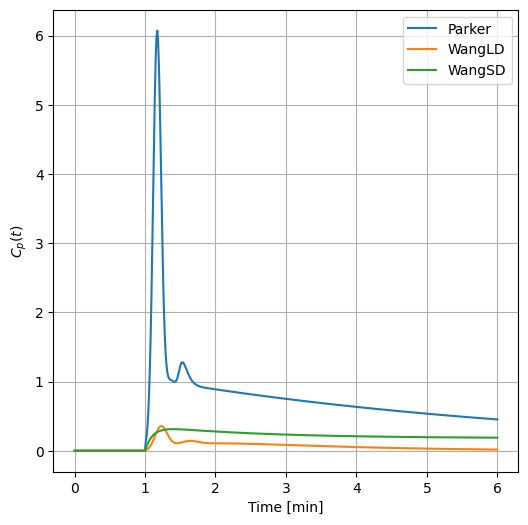

In [ ]:
# Show population AIF:
offset = 1.0 # it means, the injectio occurred at t=offset[min]
tmax = 6.0 # min
time_axis = np.linspace(0.0, tmax, num=512) # min
aif = {
        'Parker': aif_parker(time_axis=time_axis, offset=offset),
        'WangLD': aif_wang(time_axis=time_axis, mode='LD', offset=offset),
        'WangSD': aif_wang(time_axis=time_axis, mode='SD', offset=offset)
}

fig, ax = setup_subplots_figs(NROWS=1, NCOLS=1, SUBPLTSIZE=6.0)
for aifmodel, aifcurve in aif.items():
    ax[0].plot(time_axis, aifcurve, label=aifmodel)
ax[0].legend(loc='best')
ax[0].grid(True)
ax[0].set_xlabel('Time [min]')
ax[0].set_ylabel(r'$C_p(t)$')   


### Tofts Models - Single vs Extended (2 compartments)

Text(3.15, 0.6182430353784389, 'Ktrans=0.1\nve=0.1\nvp=0.1')

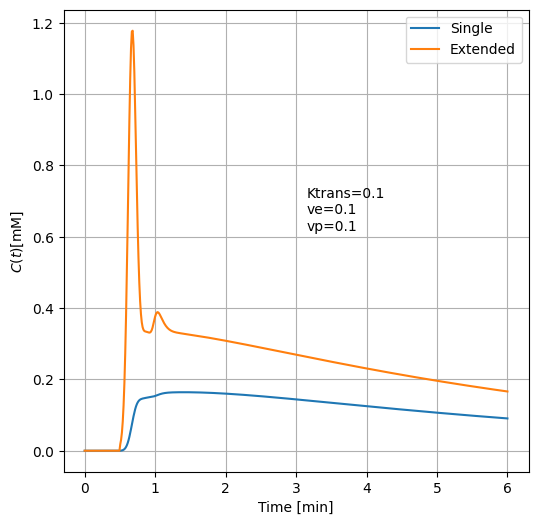

In [136]:
kpars = {'Ktrans': 0.1,
         've': 0.1,
         'vp': 0.1
        }

tmax = 6.0 # min
time_axis = np.linspace(0.0, tmax, num=512) # min
tofts = {'Single': tofts2C(time_axis, 
                           kpars['Ktrans'], 
                           kpars['ve'], 
                           vp=0.0, 
                           aif='parker', 
                           offset=0.5),
         'Extended': tofts2C(time_axis, 
                             kpars['Ktrans'], 
                             kpars['ve'], 
                             kpars['vp'], 
                             aif='parker', 
                             offset=0.5)
        }

fig, ax = setup_subplots_figs(NROWS=1, NCOLS=1, SUBPLTSIZE=6.0)
for kmodel, timecurve in tofts.items():
    ax[0].plot(time_axis, timecurve, label=kmodel)
ax[0].legend(loc='best')
ax[0].grid(True)
ax[0].set_xlabel('Time [min]')
ax[0].set_ylabel(r'$C(t)$[mM]')
ax[0].text(ax[0].get_xlim()[-1]*0.5, 
           ax[0].get_ylim()[-1]*0.5, 
           '\n'.join([f'{key}={val}' for key, val in kpars.items()]))


### Contrast agent concentration to relaxivity

The following table has been taken from https://s.mriquestions.com/what-is-relaxivity.html and is based on [Rohrer et al. Invest. Radiol 40:715-724; 2005](https://journals.lww.com/investigativeradiology/abstract/2005/11000/comparison_of_magnetic_properties_of_mri_contrast.5.aspx)


In [137]:
# Relaxivities at 1.5T & 37C (see Appendix 2)
relaxivities = {'magnevist': 4.1,
                'multihance': 6.3,
                'omniscan': 4.3,
                'dotarem': 3.6,
                'prohance': 4.1, 
                'gadavist': 5.2,
                'eovist': 6.9,
                'vueway': 12.8 
                }

r1 = relaxivities['magnevist']


In [ ]:
tissues = ['breast_fat','breast_malignant','blood','water_csf']
T10 = {tissue: tissue_parameters[tissue]['t1'] for tissue in tissues}

# 2-compartment model, assuming same parameters for all tissues
ct = tofts2C(time_axis, kpars['Ktrans'], kpars['ve'], kpars['vp'], aif='parker', offset=0.5)


Text(0, 0.5, '$T_1(C(t))$[s]')

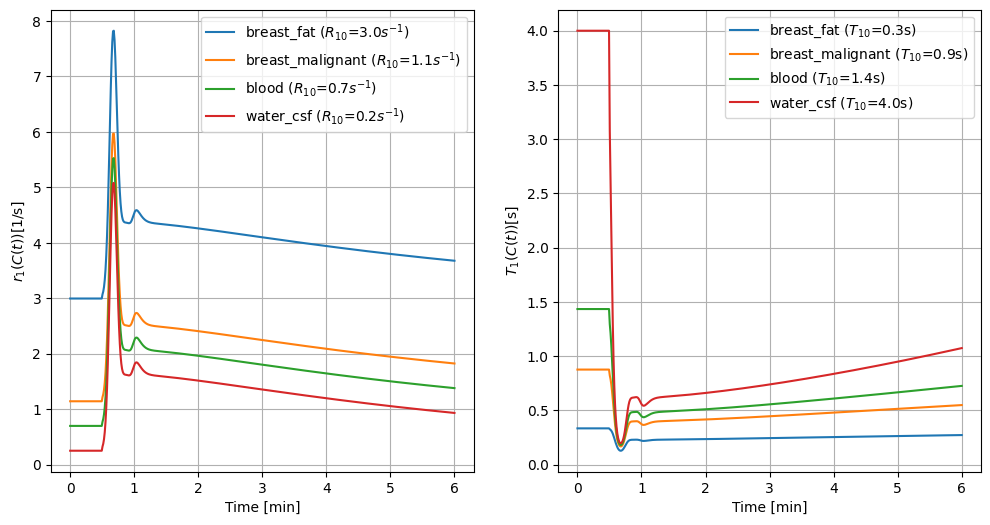

In [155]:
r1ct = {}
t1ct = {}
for tissue, t1BL in T10.items():
    r1ct[tissue] = r1_contrast(t1BL, r1, ct)
    t1ct[tissue] = 1.0/r1ct[tissue]

fig, ax = setup_subplots_figs(NROWS=1, NCOLS=2, SUBPLTSIZE=6.0)
for tissue, r1t in r1ct.items():
    ax[0].plot(time_axis, r1t, label=f'{tissue} ('+r'$R_{10}$='+f'{r1_contrast(T10[tissue], r1, 0):.1f}'+r'$s^{-1}$)')
    ax[1].plot(time_axis, t1ct[tissue], label=f'{tissue} ('+r'$T_{10}$='+f'{tissue_parameters[tissue]["t1"]/1000:.1f}s)')
ax[0].legend(loc='best')
ax[0].grid(True)
ax[0].set_xlabel('Time [min]')
ax[0].set_ylabel(r'$r_1(C(t))$[1/s]')

ax[1].legend(loc='best')
ax[1].grid(True)
ax[1].set_xlabel('Time [min]')
ax[1].set_ylabel(r'$T_1(C(t))$[s]')


### Longitudinal relaxivity to signal equation

Text(0, 0.5, 'S(t)')

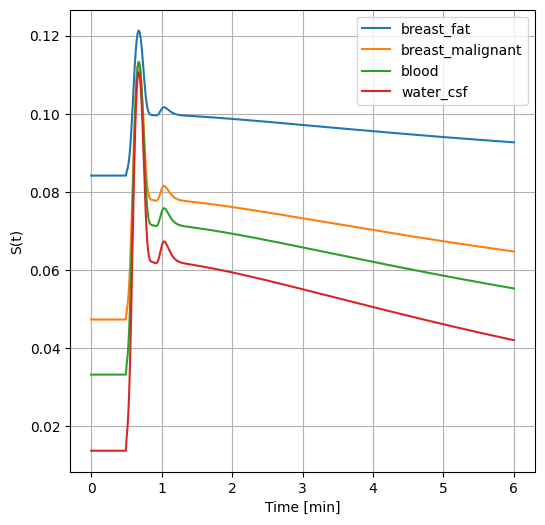

In [162]:
signal_eq = {}
for tissue, t1overTime in t1ct.items():
    signal_eq[tissue] = spgr_signal(1.0, #tissue_parameters[tissue]['m0'], #tissue_parameters[tissue]['t1'], 
                                    t1overTime*1000,
                                    aqcuisition_parameters['tr'], 
                                    aqcuisition_parameters['fa'], 
                                    aqcuisition_parameters['te'],
                                    tissue_parameters[tissue]['t2star'])

fig, ax = setup_subplots_figs(NROWS=1, NCOLS=1, SUBPLTSIZE=6.0)
for tissue, st in signal_eq.items():
    ax[0].plot(time_axis, st, label=tissue)

ax[0].legend(loc='best')
ax[0].grid(True)
ax[0].set_xlabel('Time [min]')
ax[0].set_ylabel(r'S(t)')


## Breast tumour tissue example

### Signal Equation

In [208]:
tissue = 'breast_malignant'
kpars = {'Ktrans': 0.1,
         've': 0.1,
         'vp': 0.1
        }
r1 = relaxivities['magnevist']

# Show population AIF:
time_points = np.array([0.0, 4.6, 5.6, 6.7, 7.8, 8.8])
offset = 2.5 # it means, the injectio occurred at t=offset[min]
tmax = time_points[-1] # min
tdense = np.linspace(0.0, tmax, num=512) # min

ct_continuous = tofts2C(tdense, kpars['Ktrans'], kpars['ve'], kpars['vp'], aif='parker', offset=offset)
ct_discrete = tofts2C(time_points, kpars['Ktrans'], kpars['ve'], kpars['vp'], aif='parker', offset=offset)

r1ct_continuous = r1_contrast(tissue_parameters[tissue]['t1'], r1, ct_continuous)
t1ct_continuous = 1000.0/r1ct_continuous #ms 

r1ct_discrete = r1_contrast(tissue_parameters[tissue]['t1'], r1, ct_discrete)
t1ct_discrete = 1000.0/r1ct_discrete #ms

st_continuous = spgr_signal(tissue_parameters[tissue]['m0'],
                            t1ct_continuous,
                            aqcuisition_parameters['tr'], 
                            aqcuisition_parameters['fa'], 
                            aqcuisition_parameters['te'],
                            tissue_parameters[tissue]['t2star']
                            )
S0tC = st_continuous[0]

st_discrete = spgr_signal(tissue_parameters[tissue]['m0'],
                          t1ct_discrete,
                          aqcuisition_parameters['tr'], 
                          aqcuisition_parameters['fa'], 
                          aqcuisition_parameters['te'],
                          tissue_parameters[tissue]['t2star']
                          )
S0tD = st_discrete[0]


### Semi-quantitative parameters

In [ ]:
PE_thresh = 70
PE_c = 100 * ( st_continuous - S0tC ) / S0tC
PE_d = 100 * ( st_discrete - S0tD ) / S0tD

t1, tf = time_points[[1, -1]]

S1tC = st_continuous[tdense >= t1][0]
SftC = st_continuous[tdense >= tf][0]

S1tD, SftD = st_discrete[[1, -1]]

SER_C = ( S1tC - S0tC ) / ( SftC - S0tC ) 
SER_D = ( S1tD - S0tD ) / ( SftD - S0tD ) 


Text(4.615264187866928, 85.9289155939888, 'SER = 1.75 (continuous)\nSER = 1.77 (discrete)')

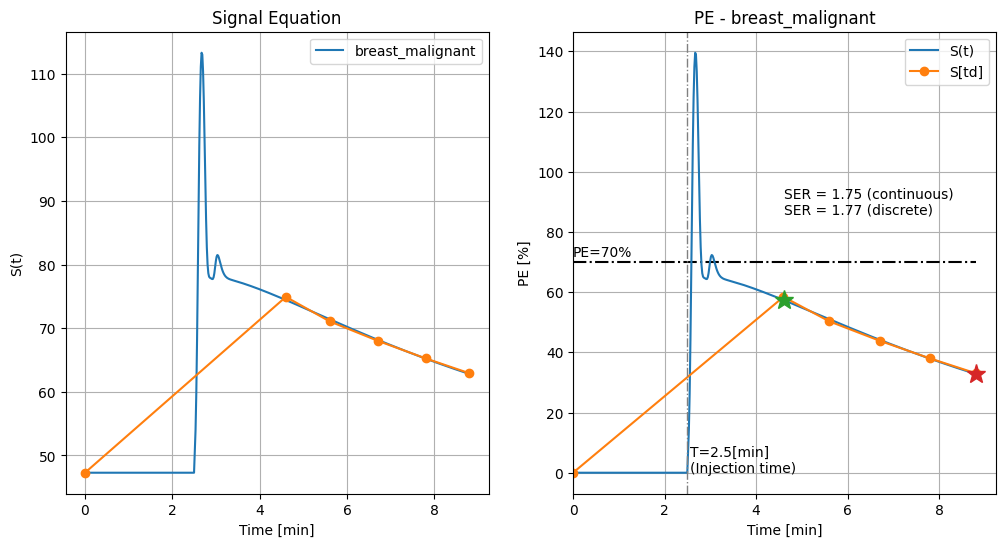

In [ ]:
fig, ax = setup_subplots_figs(NROWS=1, NCOLS=2, SUBPLTSIZE=6.0)
xlims = tdense[[0, -1]]
xlims[-1] = 1.05*xlims[-1]

# 0) Signal 
ax[0].plot(tdense, st_continuous, label=tissue)
ax[0].plot(time_points, st_discrete, '.-', markersize=12)

ax[0].legend(loc='best')
ax[0].grid(True)
ax[0].set_xlabel('Time [min]')
ax[0].set_ylabel(r'S(t)')
ax[0].set_title('Signal Equation')

# 1) PE 
ax[1].plot(tdense[[0, -1]], [PE_thresh]*2, '-.', color='black')
ax[1].text(tdense[0], 1.025*PE_thresh, f'PE={PE_thresh}%')

ax[1].plot(tdense, PE_c, label='S(t)')
ax[1].plot(time_points, PE_d, '.-', label='S[td]', markersize=12)

ax[1].set_title(f'PE - {tissue}')
ax[1].legend(loc='best')
ax[1].grid(True)
ax[1].set_xlabel('Time [min]')
ax[1].set_ylabel('PE [%]')
ax[1].set_xlim(xlims)

ylim = ax[1].get_ylim()
ax[1].plot([offset]*2, ylim, '-.', color='gray', linewidth=1)
ax[1].text(1.02*offset, 0, f'T={offset}[min]\n(Injection time)')
ax[1].set_ylim(ylim)

# 2) SER
ax[1].plot(tdense[tdense>=t1][0], 100 * (S1tC - S0tC) / S0tC, '*', markersize=14)
ax[1].plot(tdense[tdense>=tf][0], 100 * (SftC - S0tC) / S0tC, '*', markersize=14)
ax[1].text(tdense[tdense>=t1][0], 150 * (S1tC - S0tC) / S0tC, f'SER = {SER_C:.2f} (continuous)\nSER = {SER_D:.2f} (discrete)')


### Consider only signal equation (i.e. T1 baseline)

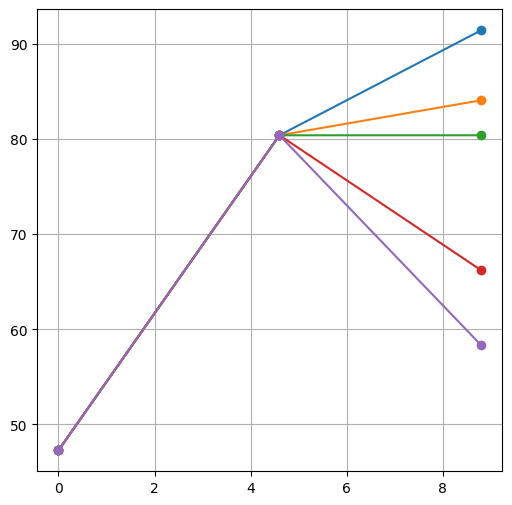

In [ ]:
S0 = spgr_signal(tissue_parameters[tissue]['m0'],
                            tissue_parameters[tissue]['t1'],
                            aqcuisition_parameters['tr'], 
                            aqcuisition_parameters['fa'], 
                            aqcuisition_parameters['te'],
                            tissue_parameters[tissue]['t2star']
                            )
SER = np.array([0.75, 0.9, 1.0, 1.75, 3.0])
PE = 70
S1 = (1 + PE/100) * S0
Sf =  S0 + ( S1 - S0 ) / (SER + 1e-6)

fig, ax = setup_subplots_figs(NROWS=1, NCOLS=1, SUBPLTSIZE=6.0)
for sfinal in Sf:
    ax[0].plot(time_points[[0, 1, -1]], [S0, S1, sfinal], 'o-')
ax[0].grid(True)
